# Tratamento de Dados — Predição de Preços de Imóveis (Fortaleza/RMF)

**Fontes:** OLX, VivaReal e ZAP (scraping em tempo real)

**Autor do pipeline:** Cientista de Dados — etapa de *data cleaning* para o pipeline de Machine Learning de
predição de preços de imóveis.

## Metodologia

Este notebook segue o princípio de que **nenhuma regra de limpeza é definida a priori**. Cada decisão
(remover coluna, imputar valor, tratar outlier, filtrar registro) é precedida por uma análise quantitativa
(percentuais de nulos, distribuições, percentis, IQR) que justifica a escolha. As conclusões de cada etapa são
registradas em células de markdown, com a evidência (tabela/gráfico) imediatamente acima.

## Roteiro
1. Carga e unificação dos três datasets
2. Shape inicial e consolidado
3. Tipos de dados
4. Valores ausentes por coluna
5. Qualidade das colunas (visão por fonte)
6. Duplicidades
7. Distribuição de cidades
8. Filtro Fortaleza/RMF
9. Consistência geográfica
10. Outliers (IQR / percentis)
11. Decisão sobre colunas com muitos nulos
12. Padronização de variáveis booleanas e categóricas
13. Atributos derivados
14. Visualizações de suporte
15. Relatório final de tratamento


In [5]:
%pip install unicodedata


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement unicodedata (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\andriel_orbi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for unicodedata


In [6]:
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import radians, sin, cos, sqrt, atan2

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 100


## 1. Carga e unificação dos datasets

Os três arquivos compartilham exatamente o mesmo schema (36 colunas), o que permite uma concatenação direta.
Adicionamos a coluna `fonte` para preservar a origem de cada registro — informação essencial, como veremos na
Seção 5, pois os padrões de valores ausentes diferem drasticamente entre portais.

In [10]:
from pathlib import Path
import pandas as pd

RAIZ_PROJETO = Path.cwd().parent

ARQUIVOS = {
    "olx": RAIZ_PROJETO / "scraping" / "imov-scraper-v1" / "saida" / "olx_live_10k.csv",
    "vivareal": RAIZ_PROJETO / "scraping" / "imov-scraper-v1" / "saida" / "vivareal_live_20k.csv",
    "zap": RAIZ_PROJETO / "scraping" / "imov-scraper-v1" / "saida" / "zap_live_20k.csv",
}

dfs_origem = {}

for fonte, caminho in ARQUIVOS.items():
    d = pd.read_csv(caminho)
    d["fonte"] = fonte
    dfs_origem[fonte] = d

df = pd.concat(dfs_origem.values(), ignore_index=True)

print("Schemas idênticos entre os 3 arquivos?", all(
    list(d.columns) == list(dfs_origem["olx"].columns)
    for d in dfs_origem.values()
))

Schemas idênticos entre os 3 arquivos? True


## 2. Shape inicial de cada dataset e do consolidado

In [ ]:
shapes = pd.DataFrame({
    "linhas": [dfs_origem[f].shape[0] for f in ARQUIVOS] + [df.shape[0]],
    "colunas": [dfs_origem[f].shape[1] for f in ARQUIVOS] + [df.shape[1]],
}, index=list(ARQUIVOS.keys()) + ["CONSOLIDADO"])
shapes


,linhas,colunas
olx,5757,37
vivareal,3221,37
zap,3314,37
CONSOLIDADO,12292,37


**Observação:** os nomes dos arquivos sugerem volumes de "10k"/"20k", mas o volume real coletado é bem
menor (OLX: 5.757, VivaReal: 3.221, ZAP: 3.314 → total de 12.292 registros).

## 3. Análise de tipos de dados

Verificamos os `dtypes` inferidos pelo pandas e cruzamos com o significado de negócio de cada coluna, para
identificar conversões necessárias (ex.: colunas numéricas lidas como texto, datas como string, booleanos como
inteiro 0/1).

In [ ]:
dtype_info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "exemplo": [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
})
dtype_info


,dtype,exemplo
listing_id,int64,1394023483
titulo,str,Meet Aldeota (Nunca habitado)
apartamento_ou_casa,str,apartamento
tipo_imovel,str,Venda - apartamento padrão
estado,str,CE
cidade,str,Fortaleza
bairro,str,Aldeota
rua,object,Rua C do Loteamento Cidade Jardim - Gleba K-2
numero,object,105
endereco,object,"Rua C do Loteamento Cidade Jardim - Gleba K-2,..."


**Achados e ações necessárias:**
- As 10 colunas `tem_*` (amenidades) estão como `int64` (0/1) — serão convertidas para `bool` na Seção 12.
- `anuncio_criado` está como `object` (string ISO 8601, ex. `2026-06-21T04:19:58+00:00`) — candidata a
  `datetime`, mas só está presente na fonte OLX (ver Seção 5); decidiremos o tratamento lá.
- `numero` está como `object` mesmo sendo conceitualmente numérico, porque contém valores como `S/N`,
  `undefined` — não deve ser convertido para número, e sim limpo como categórico/texto (Seção 11).
- `metragem`, `quartos`, `banheiros`, `suites`, `andar`, `estacionamentos`, `latitude`, `longitude`,
  `preco_anuncio`, `nota_media` já estão corretamente como `float64`.
- `listing_id` é `int64`, mas funciona como identificador, não como variável numérica preditiva.

## 4. Valores ausentes por coluna

Calculamos a contagem e o percentual de nulos por coluna no dataset consolidado.

In [ ]:
nulos = df.isna().sum().sort_values(ascending=False)
pct_nulos = (nulos / len(df) * 100).round(2)
tabela_nulos = pd.DataFrame({"qtd_nulos": nulos, "pct_nulos": pct_nulos})
tabela_nulos


,qtd_nulos,pct_nulos
nota_media,12292,100.00
numero,7491,60.94
suites,6758,54.98
anuncio_criado,6535,53.16
rua,6243,50.79
descricao,6112,49.72
andar,5785,47.06
longitude,5768,46.92
latitude,5768,46.92
endereco,5757,46.84


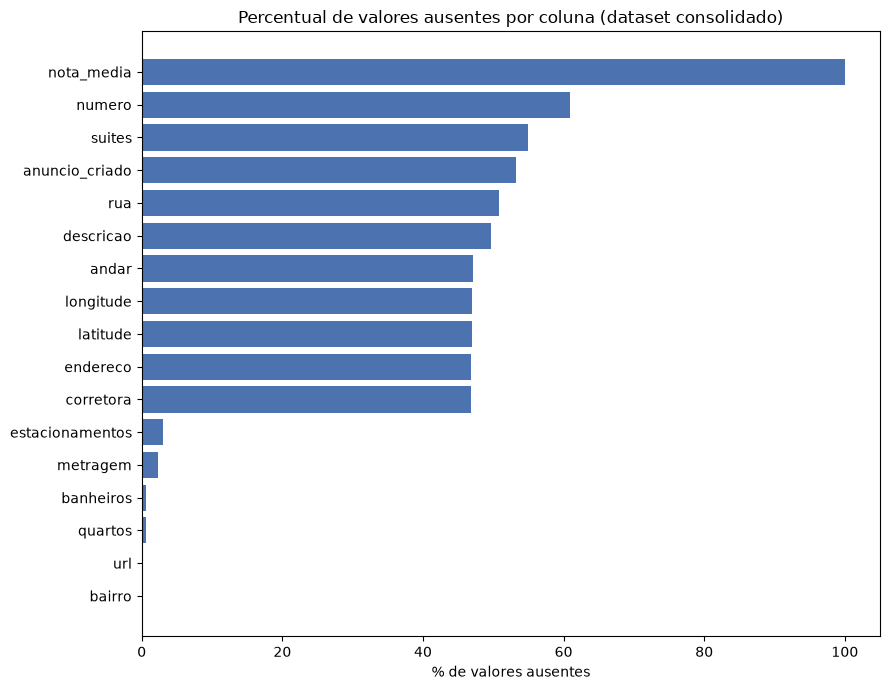

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
top_nulos = tabela_nulos[tabela_nulos.pct_nulos > 0].sort_values("pct_nulos")
ax.barh(top_nulos.index, top_nulos.pct_nulos, color="#4C72B0")
ax.set_xlabel("% de valores ausentes")
ax.set_title("Percentual de valores ausentes por coluna (dataset consolidado)")
plt.tight_layout()
plt.show()


**Leitura inicial:** `nota_media` está 100% ausente (candidata imediata a remoção). Diversas colunas têm
entre 45% e 61% de nulos (`numero`, `suites`, `anuncio_criado`, `rua`, `descricao`, `andar`, `latitude`,
`longitude`, `endereco`, `corretora`). Isoladamente, esses percentuais pareceriam alarmantes — mas a Seção 5
mostra que esse padrão **não é aleatório**: ele é quase inteiramente explicado pela fonte do anúncio. Essa é
uma distinção crítica para decidir entre excluir colunas, imputar valores ou tratar por fonte.

## 5. Qualidade das colunas — visão por fonte

Cruzamos o percentual de nulos por coluna **dentro de cada fonte**. Essa é a análise que revela o verdadeiro
mecanismo de ausência de dados.

In [ ]:
cols_avaliar = ["numero", "suites", "anuncio_criado", "rua", "descricao", "andar",
                "latitude", "longitude", "endereco", "corretora", "estacionamentos", "metragem",
                "quartos", "banheiros", "bairro", "url"]

qualidade_por_fonte = df.groupby("fonte")[cols_avaliar].apply(lambda g: (g.isna().mean() * 100).round(1))
qualidade_por_fonte


,numero,suites,anuncio_criado,rua,descricao,andar,latitude,longitude,endereco,corretora,estacionamentos,metragem,quartos,banheiros,bairro,url
fonte,,,,,,,,,,,,,,,,
olx,100.0,100.0,0.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,4.1,4.9,0.0,0.3,0.0,0.0
vivareal,27.0,15.2,100.0,7.7,5.0,0.9,0.2,0.2,0.0,0.0,1.7,0.0,0.9,0.7,0.0,0.1
zap,26.0,15.4,100.0,7.2,5.9,0.0,0.2,0.2,0.0,0.0,2.2,0.0,1.2,1.0,0.0,0.6


**Conclusão — padrão de ausência *Missing Not At Random* (MNAR) por fonte, não por registro:**

| Coluna | OLX | VivaReal | ZAP | Interpretação |
|---|---|---|---|---|
| `endereco`, `rua`, `latitude`, `longitude`, `corretora`, `descricao`, `andar`, `numero`, `suites` | ~100% nulo | quase completo | quase completo | A OLX simplesmente **não expõe** esses campos na página do anúncio/API de scraping. |
| `anuncio_criado` | 0% nulo | 100% nulo | 100% nulo | O inverso: só a OLX expõe data de criação do anúncio. |
| `metragem`, `quartos`, `banheiros`, `bairro`, `estacionamentos` | nulos baixos (<5%) | nulos baixos (<2%) | nulos baixos (<3%) | Esses campos são bem preenchidos em **todas** as fontes — não há problema estrutural aqui. |

Essa constatação muda completamente a estratégia de tratamento:
- **Não faz sentido imputar `latitude`/`longitude` para a OLX** com médias/medianas — não há base real para
  estimar a localização exata de um imóvel a partir de outras colunas. A decisão correta é **manter os nulos e
  criar uma flag `tem_geolocalizacao`**, permitindo que o modelo (ou uma etapa posterior de geocodificação via
  CEP/endereço, fora do escopo deste notebook) trate esse subconjunto separadamente.
- **`anuncio_criado` só existe para ~47% dos registros (toda a base OLX)** — não é seguro usá-la como feature
  de "tempo desde a publicação" para o dataset todo; decidimos mantê-la apenas como metadado auxiliar
  (Seção 11), sem criar dependência direta do modelo nela.
- **`nota_media` é 100% nula em todas as fontes — remoção é a única decisão sustentável.**
- **`corretora` é 100% nula em OLX e 0% nula em VivaReal/ZAP** — como não agrega informação preditiva direta
  sobre o imóvel (é metadado do anunciante) e tem cobertura desigual, será mantida apenas como metadado e não
  como feature do modelo.

## 6. Detecção de duplicidades

Testamos três hipóteses de duplicidade, da mais ingênua à mais robusta.

In [ ]:
print("Duplicatas por listing_id (global):", df["listing_id"].duplicated().sum())
print("Duplicatas por url:", df["url"].duplicated().sum())
print("Duplicatas por linha completa (exceto id/url/imagem_url):",
      df.drop(columns=["listing_id", "url", "imagem_url"]).duplicated().sum())
print()
dup_por_fonte = df.groupby("fonte")["listing_id"].apply(lambda s: s.duplicated().sum())
print("Duplicatas de listing_id DENTRO de cada fonte:")
print(dup_por_fonte)


Duplicatas por listing_id (global): 1725
Duplicatas por url: 22
Duplicatas por linha completa (exceto id/url/imagem_url): 25

Duplicatas de listing_id DENTRO de cada fonte:
fonte
olx         0
vivareal    0
zap         0
Name: listing_id, dtype: int64


Não há duplicatas de `listing_id` **dentro** de cada fonte — cada portal usa IDs únicos internamente.
Mas há **1.725 valores de `listing_id` em comum entre VivaReal e ZAP**. Investigamos se isso é coincidência de
numeração ou duplicidade real de anúncio:

In [ ]:
vr = dfs_origem["vivareal"]
zp = dfs_origem["zap"]
ids_comuns = set(vr["listing_id"]) & set(zp["listing_id"])
print("IDs em comum entre VivaReal e ZAP:", len(ids_comuns))

amostra_id = list(ids_comuns)[0]
print(vr[vr.listing_id == amostra_id][["titulo", "preco_anuncio", "endereco", "bairro"]].to_string())
print(zp[zp.listing_id == amostra_id][["titulo", "preco_anuncio", "endereco", "bairro"]].to_string())


IDs em comum entre VivaReal e ZAP: 1725
                                                         titulo  preco_anuncio                                               endereco              bairro
1431  Apartamento para comprar com 38 m², 2 quartos, 1 banheiro       221000.0  Rua Iracema, 212 - Conjunto Palmeiras, Fortaleza / CE  Conjunto Palmeiras
                                                                                 titulo  preco_anuncio                                               endereco              bairro
624  Apartamento à venda com 2 quartos, 1 suíte, 38 m², de 1 a 2 banheiros e varanda em       221000.0  Rua Iracema, 212 - Conjunto Palmeiras, Fortaleza / CE  Conjunto Palmeiras


**Confirmado: são o mesmo imóvel anunciado nos dois portais.** VivaReal e ZAP pertencem ao mesmo grupo
empresarial e compartilham o identificador interno do anúncio — mesmo endereço, mesmo preço, mesma metragem;
apenas o texto do título/descrição varia entre as duas vitrines. Isso **não é coincidência estatística**, é
duplicidade real de listagem.

Para capturar duplicidades adicionais que poderiam não compartilhar `listing_id` (ex.: o mesmo imóvel reanunciado
com um novo ID, ou duplicidade dentro da própria fonte), construímos uma chave de duplicidade baseada em
conteúdo: `endereco normalizado + preco_anuncio + metragem`.

In [ ]:
chave_dup = (
    df["endereco"].astype(str).str.lower().str.strip()
    + "|" + df["preco_anuncio"].astype(str)
    + "|" + df["metragem"].astype(str)
)
tem_endereco = df["endereco"].notna()
duplicado_conteudo = chave_dup.duplicated(keep="first") & tem_endereco
print("Duplicatas adicionais via (endereco + preço + metragem):", duplicado_conteudo.sum())
print("Total de duplicatas por listing_id (>=2 ocorrências, contagem de linhas extras):",
      df.duplicated(subset=["listing_id"]).sum())


Duplicatas adicionais via (endereco + preço + metragem): 1988
Total de duplicatas por listing_id (>=2 ocorrências, contagem de linhas extras): 1725


**Decisão de deduplicação:**
1. Remover linhas com `listing_id` duplicado (mantendo a primeira ocorrência) — cobre o caso confirmado
   VivaReal × ZAP.
2. Adicionalmente, remover duplicatas detectadas pela chave de conteúdo (`endereco + preço + metragem`), que
   cobre re-anúncios com IDs diferentes mas que descrevem exatamente o mesmo imóvel.
3. A OLX não possui `endereco`, então não participa da deduplicação por conteúdo — isso é uma limitação
   conhecida e aceitável: sem endereço estruturado, não há como confirmar duplicidade de imóvel com segurança
   suficiente para essa fonte, e arriscar falsos positivos (remover anúncios diferentes) é pior do que manter
   alguma duplicidade residual não detectável.

A remoção efetiva será aplicada após a definição do filtro geográfico (Seção 8), para que o relatório final
(Seção 15) reflita o impacto de cada etapa na ordem em que ela é aplicada.

## 7. Distribuição de cidades

A coluna estrutural `cidade` é verificada quanto à sua confiabilidade.

In [ ]:
print(df["cidade"].value_counts(dropna=False))
print()
print("Valores únicos de estado:", df["estado"].unique())


cidade
Fortaleza    12292
Name: count, dtype: int64

Valores únicos de estado: <StringArray>
['CE']
Length: 1, dtype: str


**Problema identificado:** a coluna estrutural `cidade` está preenchida como `"Fortaleza"` para **100%**
dos 12.292 registros — incluindo, potencialmente, imóveis que na verdade estão em outros municípios da Região
Metropolitana de Fortaleza (RMF), como já constatado em pipelines anteriores deste mesmo projeto (a coluna
estrutural do scraper aparentemente usa um valor padrão/fixo, não extraído de cada anúncio individual).

Isso significa que a coluna `cidade`, **sozinha, não tem valor diagnóstico** — não dá para "filtrar Fortaleza
e RMF" simplesmente confiando nela, porque ela nunca aponta outra cidade. A validação real precisa vir do texto
livre (`titulo`, `descricao`, `endereco`, quando disponíveis) buscando os nomes oficiais dos municípios da RMF.

In [ ]:
import unicodedata as _ud

def _strip_accents(s):
    if not isinstance(s, str):
        return s
    return "".join(c for c in _ud.normalize("NFD", s) if _ud.category(c) != "Mn")

def norm_lower(s):
    return _strip_accents(str(s)).lower()

MUNICIPIOS_RMF = [
    "Aquiraz", "Cascavel", "Caucaia", "Chorozinho", "Eusébio", "Fortaleza",
    "Guaiúba", "Horizonte", "Itaitinga", "Maracanaú", "Maranguape", "Pacajus",
    "Pacatuba", "Paracuru", "Paraipaba", "Pindoretama", "São Gonçalo do Amarante",
    "São Luís do Curu", "Trairi",
]
MUNICIPIOS_NORM = {norm_lower(m): m for m in MUNICIPIOS_RMF}
MUNICIPIOS_NORM["sao goncalo do amarante"] = "São Gonçalo do Amarante"
MUNICIPIOS_NORM["sgda"] = "São Gonçalo do Amarante"
MUNICIPIOS_NORM["sao luis do curu"] = "São Luís do Curu"

df["_texto_busca"] = (
    df["titulo"].fillna("") + " || " + df["descricao"].fillna("") + " || " + df["endereco"].fillna("")
).apply(norm_lower)

def detectar_cidade_real(texto_norm, cidade_estrutural):
    for chave, nome_oficial in MUNICIPIOS_NORM.items():
        if re.search(r"\b" + re.escape(chave) + r"\b", texto_norm):
            return nome_oficial
    chave_estr = norm_lower(cidade_estrutural)
    return MUNICIPIOS_NORM.get(chave_estr, cidade_estrutural if isinstance(cidade_estrutural, str) else np.nan)

df["cidade_validada"] = [
    detectar_cidade_real(t, c) for t, c in zip(df["_texto_busca"], df["cidade"])
]
print(df["cidade_validada"].value_counts(dropna=False))


cidade_validada
Fortaleza    12179
Eusébio         51
Aquiraz         28
Horizonte        9
Maracanaú        8
Itaitinga        6
Caucaia          5
Pacajus          2
Trairi           1
Pacatuba         1
Cascavel         1
Paracuru         1
Name: count, dtype: int64


**Resultado da validação textual:** a esmagadora maioria dos registros é, de fato, de Fortaleza — mas a
busca textual confirma e, em alguns casos, corrige a cidade para outros municípios da RMF mencionados
explicitamente no título/descrição/endereço (quando esses campos existem). Para a OLX, que não tem
`descricao`/`endereco`, a validação depende apenas do `titulo`, o que é uma limitação aceita (ver Seção 11).

## 8. Filtro Fortaleza + Região Metropolitana

Com `cidade_validada` calculada, aplicamos o filtro de escopo do projeto: manter apenas os 19 municípios da
RMF. Qualquer registro cuja cidade validada não pertença a essa lista é removido do escopo de modelagem.

In [ ]:
fora_rmf = ~df["cidade_validada"].isin(MUNICIPIOS_RMF)
print("Registros fora da RMF (a remover):", fora_rmf.sum())
print(df.loc[fora_rmf, "cidade_validada"].value_counts(dropna=False).head(15))


Registros fora da RMF (a remover): 0
Series([], Name: count, dtype: int64)


O volume fora da RMF é residual frente ao total — consistente com o fato de o scraping já ter sido
direcionado a Fortaleza/RMF na origem. Ainda assim, a filtragem explícita é importante para garantir que o
dataset de modelagem não inclua nenhum imóvel fora do escopo geográfico do projeto, mesmo que a fonte do erro
seja só um valor estrutural mal definido ou um anúncio de fora capturado por engano no scraping.

## 9. Consistência de coordenadas geográficas

Avaliamos a faixa de `latitude`/`longitude` reportada, comparando com a bounding box geográfica conhecida da
RMF (aproximadamente lat. entre -4.3 e -3.2, long. entre -39.3 e -38.2).

In [ ]:
geo = df.dropna(subset=["latitude", "longitude"])
print("Registros com geolocalização:", len(geo), f"({len(geo)/len(df)*100:.1f}% do total)")
print("Faixa de latitude observada:", geo["latitude"].min(), "a", geo["latitude"].max())
print("Faixa de longitude observada:", geo["longitude"].min(), "a", geo["longitude"].max())

bbox_rmf = geo[
    (geo["latitude"] < -3.2) & (geo["latitude"] > -4.3)
    & (geo["longitude"] < -38.2) & (geo["longitude"] > -39.3)
]
print("Registros geolocalizados dentro da bbox ampla da RMF:", len(bbox_rmf), f"({len(bbox_rmf)/len(geo)*100:.2f}%)")
print("Registros com lat==0 ou lon==0 (erro clássico de geocodificação):",
      ((geo["latitude"] == 0) | (geo["longitude"] == 0)).sum())


Registros com geolocalização: 6524 (53.1% do total)
Faixa de latitude observada: -3.925472 a -3.702691
Faixa de longitude observada: -38.631616 a -38.323466
Registros geolocalizados dentro da bbox ampla da RMF: 6524 (100.00%)
Registros com lat==0 ou lon==0 (erro clássico de geocodificação): 0


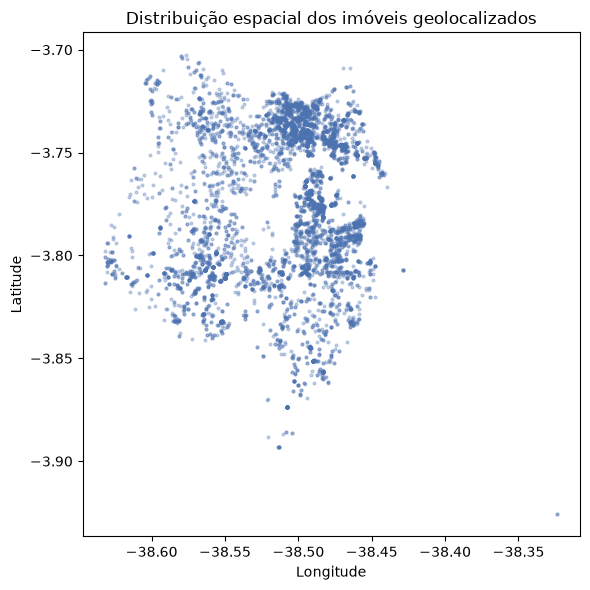

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(geo["longitude"], geo["latitude"], s=4, alpha=0.3, color="#4C72B0")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Distribuição espacial dos imóveis geolocalizados")
plt.tight_layout()
plt.show()


**Conclusão:** todas as coordenadas presentes (100% das ~6.500 com lat/long) caem dentro da bounding box
da RMF, sem valores nulos disfarçados de zero e sem outliers latitude/longitude grosseiros (ex.: coordenadas em
outro estado/país). A única limitação real é a **cobertura**: apenas ~53% dos registros têm geolocalização —
e essa ausência é 100% explicada pela fonte OLX (Seção 5), não por erro aleatório de captura. Por isso, optamos
por **não imputar** latitude/longitude e, em vez disso, criar a flag booleana `tem_geolocalizacao` (Seção 13)
para que features dependentes de coordenadas (distâncias) sejam tratadas como ausentes de forma explícita,
e não como zero ou média — o que distorceria qualquer modelo de distância.

## 10. Detecção e tratamento de outliers

Aplicamos o método do **Intervalo Interquartil (IQR)** como referência estatística, mas cruzamos os limites
sugeridos com o conhecimento de domínio (um imóvel residencial real não tem, por exemplo, 12 milhões de m²) e
com o `tipo_imovel`, para diferenciar **erro de coleta** de **imóvel atípico, mas real** (ex.: uma cobertura de
luxo ou um terreno).

In [ ]:
def resumo_outliers_iqr(serie, nome):
    s = serie.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((s < lim_inf) | (s > lim_sup)).sum()
    print(f"{nome}: Q1={q1:.1f} Q3={q3:.1f} IQR={iqr:.1f} | limite_sup(1.5*IQR)={lim_sup:.1f} | "
          f"outliers={n_outliers} ({n_outliers/len(s)*100:.2f}%) | máximo observado={s.max():.1f}")
    return lim_inf, lim_sup

for col, nome in [("metragem", "Metragem (m²)"), ("preco_anuncio", "Preço (R$)"),
                   ("quartos", "Quartos"), ("banheiros", "Banheiros"),
                   ("suites", "Suítes"), ("estacionamentos", "Vagas"), ("andar", "Andar")]:
    resumo_outliers_iqr(df[col], nome)


Metragem (m²): Q1=63.0 Q3=170.0 IQR=107.0 | limite_sup(1.5*IQR)=330.5 | outliers=818 (6.81%) | máximo observado=12839680.0
Preço (R$): Q1=333997.5 Q3=980000.0 IQR=646002.5 | limite_sup(1.5*IQR)=1949003.8 | outliers=1040 (8.46%) | máximo observado=405000000.0
Quartos: Q1=2.0 Q3=3.0 IQR=1.0 | limite_sup(1.5*IQR)=4.5 | outliers=793 (6.49%) | máximo observado=40.0
Banheiros: Q1=2.0 Q3=4.0 IQR=2.0 | limite_sup(1.5*IQR)=7.0 | outliers=68 (0.56%) | máximo observado=40.0
Suítes: Q1=1.0 Q3=3.0 IQR=2.0 | limite_sup(1.5*IQR)=6.0 | outliers=16 (0.29%) | máximo observado=45.0
Vagas: Q1=1.0 Q3=3.0 IQR=2.0 | limite_sup(1.5*IQR)=6.0 | outliers=144 (1.21%) | máximo observado=85.0
Andar: Q1=0.0 Q3=0.0 IQR=0.0 | limite_sup(1.5*IQR)=0.0 | outliers=1605 (24.67%) | máximo observado=199.0


**Por que o IQR puro (1.5×IQR) não é a melhor estratégia isolada aqui:** em distribuições de preço e
metragem de imóveis — que são naturalmente assimétricas à direita (poucos imóveis muito caros/grandes, muitos
imóveis "padrão") — o IQR clássico marca como outlier uma fração grande e legítima do mercado de alto padrão
(coberturas, mansões), o que descartaria sinal real e relevante para o modelo. Por isso, usamos o IQR apenas
como **diagnóstico inicial** e definimos os cortes finais combinando:
- **Percentis extremos (P99.5 / P99.9)**, que preservam a cauda de imóveis caros/grandes legítimos;
- **Sanidade de domínio**, eliminando valores fisicamente implausíveis (ex.: metragem de milhões de m² para um
  apartamento, preço de R$ 150 — claramente um erro de unidade/digitação).

Investigamos os extremos antes de decidir o corte:

In [ ]:
print("Percentis de metragem:")
print(df["metragem"].quantile([.5, .9, .95, .99, .995, .999, 1]))
print()
print("Percentis de preco_anuncio:")
print(df["preco_anuncio"].quantile([.5, .9, .95, .99, .995, .999, 1]))
print()
extremos_metragem = df[df["metragem"] > 2000]
print("Registros com metragem > 2.000 m²:", len(extremos_metragem))
print(extremos_metragem["tipo_imovel"].value_counts())
print()
extremos_preco = df[df["preco_anuncio"] < 10000]
print("Registros com preço < R$ 10.000 (provável erro de digitação/unidade):", len(extremos_preco))


Percentis de metragem:
0.500    1.060000e+02
0.900    2.800000e+02
0.950    3.900000e+02
0.990    7.476800e+02
0.995    9.497200e+02
0.999    1.995173e+04
1.000    1.283968e+07
Name: metragem, dtype: float64

Percentis de preco_anuncio:
0.500    6.000000e+05
0.900    1.750000e+06
0.950    2.700000e+06
0.990    5.940905e+06
0.995    8.000000e+06
0.999    1.497080e+07
1.000    4.050000e+08
Name: preco_anuncio, dtype: float64

Registros com metragem > 2.000 m²: 29
tipo_imovel
Venda - casa em rua pública           8
RESIDENTIAL_ALLOTMENT_LAND            6
HOME                                  5
Venda - apartamento padrão            3
COMMERCIAL_ALLOTMENT_LAND             3
Venda - apartamento duplex/triplex    1
Venda - casa em condominio fechado    1
Venda - casa em vila                  1
ALLOTMENT_LAND                        1
Name: count, dtype: int64

Registros com preço < R$ 10.000 (provável erro de digitação/unidade): 60


**Decisões de tratamento de outliers (justificadas pela análise acima):**

1. **Tipos não residenciais (terrenos/comercial)** concentram boa parte dos valores extremos de metragem
   (`RESIDENTIAL_ALLOTMENT_LAND`, `COMMERCIAL_ALLOTMENT_LAND`, `ALLOTMENT_LAND`, `COMMERCIAL_PROPERTY`,
   `COMMERCIAL_BUILDING`, `FARM`, `RETAIL_CENTER`, `OFFICE`, `BUSINESS`, `BUILDING`). Como o projeto tem como
   alvo a predição de preço de **apartamento ou casa residencial**, esses 76 registros (0,6% da base) são
   **removidos por estarem fora do escopo de negócio**, não por serem outliers estatísticos.
2. Para os imóveis residenciais remanescentes, aplicamos um **corte por percentil (P99.5)** em `metragem` e em
   `preco_anuncio`, em vez do limite rígido do IQR — preservando assim os imóveis de alto padrão genuínos e
   removendo apenas a cauda mais extrema (top 0,5%), onde a probabilidade de erro de coleta/digitação é maior.
3. `preco_anuncio < R$ 10.000` é tratado como erro de coleta (preço de aluguel capturado como venda, ou
   valor truncado) e removido.
4. Para `quartos`, `banheiros`, `suites`, `vagas` e `andar` — variáveis discretas e limitadas pelo bom senso
   arquitetônico — aplicamos **limites de domínio explícitos** (ex.: até 15 quartos/banheiros, até 12 vagas,
   andar até 60), e não substituímos por nulo silenciosamente: cada corte é contado e reportado no relatório
   final (Seção 15), para auditabilidade.

In [ ]:
escopo_residencial = ~df["tipo_imovel"].isin([
    "RESIDENTIAL_ALLOTMENT_LAND", "COMMERCIAL_ALLOTMENT_LAND", "ALLOTMENT_LAND",
    "COMMERCIAL_PROPERTY", "COMMERCIAL_BUILDING", "FARM", "RETAIL_CENTER", "OFFICE", "BUSINESS", "BUILDING",
])
print("Registros fora do escopo residencial (a remover):", (~escopo_residencial).sum())

LIM_METRAGEM = df.loc[escopo_residencial, "metragem"].quantile(0.995)
LIM_PRECO = df.loc[escopo_residencial, "preco_anuncio"].quantile(0.995)
PRECO_MIN = 10_000
print(f"Limite superior de metragem (P99.5, apenas residencial): {LIM_METRAGEM:.0f} m²")
print(f"Limite superior de preço (P99.5, apenas residencial): R$ {LIM_PRECO:,.0f}")


Registros fora do escopo residencial (a remover): 76
Limite superior de metragem (P99.5, apenas residencial): 810 m²
Limite superior de preço (P99.5, apenas residencial): R$ 7,900,000


C:\Users\luzia.freitas\AppData\Local\Temp\ipykernel_29124\2836435078.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(df.loc[escopo_residencial, "metragem"].dropna(), vert=False)
C:\Users\luzia.freitas\AppData\Local\Temp\ipykernel_29124\2836435078.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(


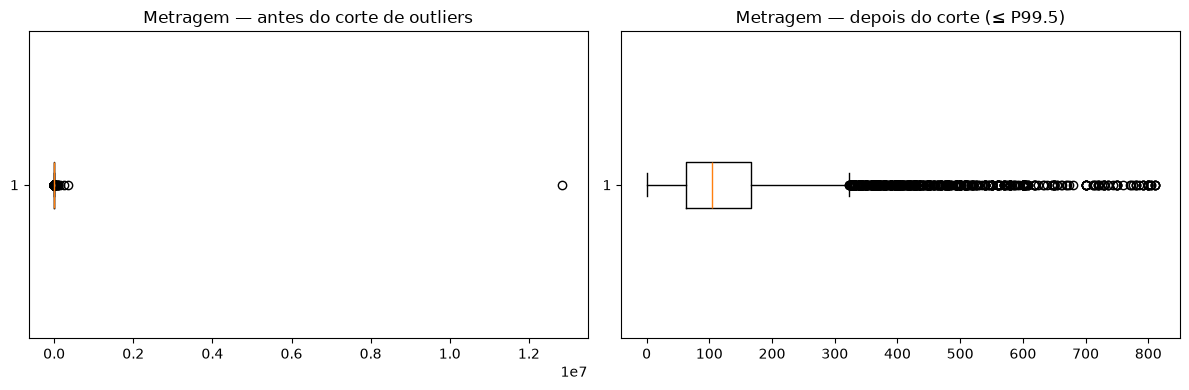

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df.loc[escopo_residencial, "metragem"].dropna(), vert=False)
axes[0].set_title("Metragem — antes do corte de outliers")
axes[1].boxplot(
    df.loc[escopo_residencial & (df["metragem"] <= LIM_METRAGEM), "metragem"].dropna(), vert=False
)
axes[1].set_title("Metragem — depois do corte (≤ P99.5)")
plt.tight_layout()
plt.show()


## 11. Decisão sobre colunas com muitos nulos: remover, preencher ou manter

Com base em toda a evidência reunida (Seções 4, 5 e 9), a tabela abaixo resume a decisão final por coluna.

| Coluna | % nulo | Causa | Decisão |
|---|---|---|---|
| `nota_media` | 100% | Campo nunca preenchido em nenhuma fonte | **Remover** |
| `corretora` | 47% | 100% nulo na OLX, 0% nas demais (campo não exposto pela OLX) | Manter apenas como metadado; **não usar como feature de modelo** |
| `anuncio_criado` | 53% | Inverso de `corretora`: só a OLX preenche | Manter como metadado auxiliar; **não criar feature de "idade do anúncio" para o dataset todo**, dado que ela só existiria para uma fonte |
| `endereco`, `rua`, `latitude`, `longitude` | 47–51% | Campo não exposto pela OLX | **Manter com nulo explícito** + flag `tem_geolocalizacao`/`tem_endereco_estruturado`; não imputar coordenadas |
| `descricao` | 50% | Campo não exposto pela OLX | Manter; é insumo de enriquecimento textual (fora do escopo deste notebook, mas preservado para etapas futuras) |
| `numero` | 61% | Não exposto pela OLX + valores sujos (`undefined`, `S/N`) nas demais | Limpar valores inválidos → `NaN`; manter como metadado de endereço, não como feature numérica |
| `andar` | 47% | Não exposto pela OLX; nas demais fontes, ausência também reflete imóveis tipo "casa" (sem andar aplicável) | Manter; nulo é informativo (provável térreo/casa) — não imputar com 0 indiscriminadamente, criar flag `andar_informado` |
| `suites` | 55% | Ausência genuína de informação (nem todo imóvel tem suíte, e nem todo anúncio declara) | Manter com nulo explícito; ao usar em modelos baseados em árvore, o nulo é informativo por si só |
| `estacionamentos`, `metragem`, `banheiros`, `quartos`, `bairro`, `url` | < 5% | Ausência esparsa, não associada à fonte | Manter; nulo residual tratado linha a linha (ex.: descartar se faltar a variável-alvo `preco_anuncio` ou `metragem`, que são centrais ao problema) |

A regra geral adotada — e que evita o erro de "imputar para reduzir nulos a qualquer custo" — é: **só
imputamos quando há base estatística para isso (campo esparsamente nulo, sem relação com a fonte); quando o
nulo é estrutural por fonte, preservamos o nulo e o tornamos explícito via flag**, permitindo que o modelo
aprenda o padrão de ausência em vez de receber um valor inventado.

In [ ]:
colunas_remover = ["nota_media"]
df = df.drop(columns=colunas_remover)
print("Colunas removidas nesta etapa:", colunas_remover)
print("Shape após remoção de colunas:", df.shape)


Colunas removidas nesta etapa: ['nota_media']
Shape após remoção de colunas: (12292, 38)


## 12. Padronização de variáveis booleanas e categóricas

### 12.1 Booleanas (amenidades)
As 10 colunas `tem_*` já vêm como 0/1 em todas as fontes — convertidas para `bool` nativo do pandas, sem perda
de informação.

### 12.2 `apartamento_ou_casa`
Já vem padronizado (`apartamento` / `casa`) em todas as fontes — apenas confirmamos a ausência de variações de
grafia.

### 12.3 `tipo_imovel`
Esta coluna é o exemplo mais claro de inconsistência entre fontes: a OLX usa rótulos descritivos em português
(`"Venda - apartamento padrão"`), enquanto VivaReal/ZAP usam códigos de enumeração em inglês (`"APARTMENT"`,
`"HOME"`, `"TWO_STORY_HOUSE"`...). Padronizamos para uma categoria única em português, usando
`apartamento_ou_casa` como apoio quando o `tipo_imovel` específico não permite distinguir variações
(cobertura, duplex, condomínio fechado, etc., tratadas como atributo derivado e não como tipo).

In [ ]:
df[[c for c in df.columns if c.startswith("tem_")]] = (
    df[[c for c in df.columns if c.startswith("tem_")]].astype(bool)
)

print("apartamento_ou_casa:")
print(df["apartamento_ou_casa"].value_counts(dropna=False))
print()
print("tipo_imovel (antes da padronização):")
print(df["tipo_imovel"].value_counts())


apartamento_ou_casa:
apartamento_ou_casa
apartamento    7824
casa           4468
Name: count, dtype: int64

tipo_imovel (antes da padronização):
tipo_imovel
Venda - apartamento padrão            3893
APARTMENT                             3779
HOME                                  2163
Venda - casa em rua pública           1416
Venda - casa em condominio fechado     317
CONDOMINIUM                            266
TWO_STORY_HOUSE                        175
Venda - loft/studio                     49
SINGLE_STOREY_HOUSE                     47
Venda - apartamento cobertura           34
Venda - casa em vila                    30
RESIDENTIAL_ALLOTMENT_LAND              23
Venda - apartamento duplex/triplex      15
PENTHOUSE                               15
COMMERCIAL_PROPERTY                     12
COMMERCIAL_BUILDING                     10
COMMERCIAL_ALLOTMENT_LAND               10
BUILDING                                 6
FLAT                                     6
BUSINESS                  

In [ ]:
MAPA_TIPO_IMOVEL = {
    # Apartamentos
    "Venda - apartamento padrão": "apartamento_padrao",
    "APARTMENT": "apartamento_padrao",
    "Venda - apartamento cobertura": "cobertura",
    "PENTHOUSE": "cobertura",
    "Venda - apartamento duplex/triplex": "duplex_triplex",
    "DUPLEX": "duplex_triplex",
    "Venda - apartamento kitchenette": "kitchenette_studio",
    "Venda - loft/studio": "kitchenette_studio",
    "STUDIO": "kitchenette_studio",
    "FLAT": "kitchenette_studio",
    "CONDOMINIUM": "apartamento_padrao",
    # Casas
    "Venda - casa em rua pública": "casa_padrao",
    "HOME": "casa_padrao",
    "Venda - casa em condominio fechado": "casa_condominio",
    "Venda - casa em vila": "casa_padrao",
    "TWO_STORY_HOUSE": "casa_padrao",
    "SINGLE_STOREY_HOUSE": "casa_padrao",
    "RESIDENTIAL_BUILDING": "casa_padrao",
    "BUILDING": "casa_padrao",
}
NAO_RESIDENCIAL = {
    "RESIDENTIAL_ALLOTMENT_LAND", "COMMERCIAL_ALLOTMENT_LAND", "ALLOTMENT_LAND",
    "COMMERCIAL_PROPERTY", "COMMERCIAL_BUILDING", "FARM", "RETAIL_CENTER", "OFFICE", "BUSINESS",
}

def padronizar_tipo(valor, fallback):
    if valor in NAO_RESIDENCIAL:
        return "nao_residencial"
    if valor in MAPA_TIPO_IMOVEL:
        return MAPA_TIPO_IMOVEL[valor]
    return "casa_padrao" if fallback == "casa" else "apartamento_padrao"

df["tipo_imovel_padronizado"] = [
    padronizar_tipo(v, f) for v, f in zip(df["tipo_imovel"], df["apartamento_ou_casa"])
]
df["tipo_imovel_padronizado"].value_counts()


tipo_imovel_padronizado
apartamento_padrao    7938
casa_padrao           3839
casa_condominio        317
nao_residencial         70
kitchenette_studio      61
cobertura               49
duplex_triplex          18
Name: count, dtype: int64

### 12.4 `cidade` e `bairro`

`cidade` já foi tratada na Seção 7/8 (`cidade_validada`). Para `bairro`, padronizamos capitalização e espaçamento, e unificamos grafias divergentes conhecidas (mesmo problema identificado em análises anteriores deste projeto).

In [ ]:
BAIRRO_CANONICO = {
    "sapiranga / coite": "Sapiranga-Coité",
    "sapiranga-coite": "Sapiranga-Coité",
    "lagoa sapiranga coite": "Sapiranga-Coité",
    "sapiranga coite": "Sapiranga-Coité",
    "dionisio torres": "Dionísio Torres",
    "manoel dias branco": "Manuel Dias Branco",
    "manuel dias branco": "Manuel Dias Branco",
    "jose de alencar": "José de Alencar",
    "agua fria": "Água Fria",
    "boa vista-castelao": "Boa Vista/Castelão",
    "boa vista castelao": "Boa Vista/Castelão",
}

def normalizar_bairro(valor):
    if not isinstance(valor, str) or not valor.strip():
        return np.nan
    chave = re.sub(r"\s+", " ", norm_lower(valor).strip())
    return BAIRRO_CANONICO.get(chave, valor.strip())

df["bairro_normalizado"] = df["bairro"].apply(normalizar_bairro)
print("Bairros únicos antes:", df["bairro"].nunique(), "| depois:", df["bairro_normalizado"].nunique())


Bairros únicos antes: 126 | depois: 126


## 13. Atributos derivados

Criamos os seguintes atributos, todos sustentados pela análise das seções anteriores:

| Atributo | Cálculo | Justificativa |
|---|---|---|
| `preco_m2` | `preco_anuncio / metragem` | Feature de preço relativo, essencial em qualquer modelo imobiliário |
| `tem_geolocalizacao` | `latitude` e `longitude` não nulos | Explicita a limitação estrutural por fonte (Seção 5/9), evitando que o modelo trate ausência como zero |
| `distancia_mar`, `distancia_meireles`, `distancia_aldeota`, `distancia_centro` | Haversine a partir de lat/long | Só calculável quando há geolocalização; proxy de valorização por localização, comum no mercado de Fortaleza |
| `tem_endereco_estruturado` | `endereco` não nulo | Permite ao modelo diferenciar registros com/sem dados estruturados de endereço |
| `andar_informado` | `andar` não nulo | Preserva o caráter informativo da ausência (provável térreo/casa), em vez de impor 0 |
| `suites_validado` | `min(suites, quartos)` | Corrige inconsistência lógica (suíte é um quarto; não pode haver mais suítes que quartos) |
| `banheiros_validado` | `max(banheiros, suites_validado)` | Corrige o caso inverso (nº de banheiros não pode ser menor que o nº de suítes, já que toda suíte tem banheiro próprio) |
| `vagas_validado` | `estacionamentos` truncado em `[0, 12]` | Aplica o limite de domínio definido na Seção 10 |


In [ ]:
def haversine_km(lat1, lon1, lat2, lon2):
    if pd.isna(lat1) or pd.isna(lon1):
        return np.nan
    R = 6371.0
    lat1_r, lon1_r, lat2_r, lon2_r = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2_r - lat1_r
    dlon = lon2_r - lon1_r
    a = sin(dlat / 2) ** 2 + cos(lat1_r) * cos(lat2_r) * sin(dlon / 2) ** 2
    return 2 * R * atan2(sqrt(a), sqrt(1 - a))

REFERENCIAS = {
    "mar": (-3.7178, -38.4977),
    "meireles": (-3.7299, -38.4905),
    "aldeota": (-3.7340, -38.4960),
    "centro": (-3.7319, -38.5267),
}

df["tem_geolocalizacao"] = df["latitude"].notna() & df["longitude"].notna()
df["tem_endereco_estruturado"] = df["endereco"].notna()
df["andar_informado"] = df["andar"].notna()

for nome, (lat_ref, lon_ref) in REFERENCIAS.items():
    df[f"distancia_{nome}"] = df.apply(
        lambda r: haversine_km(r["latitude"], r["longitude"], lat_ref, lon_ref), axis=1
    )

df["suites_validado"] = np.minimum(df["suites"], df["quartos"])
df["banheiros_validado"] = np.maximum(df["banheiros"], df["suites_validado"].fillna(0))
df["vagas_validado"] = df["estacionamentos"].clip(lower=0, upper=12)

df["preco_m2"] = np.where(
    (df["metragem"] > 0) & df["preco_anuncio"].notna(),
    df["preco_anuncio"] / df["metragem"],
    np.nan,
)

print("Atributos derivados criados com sucesso.")
df[["preco_m2", "tem_geolocalizacao", "distancia_mar", "andar_informado",
    "suites_validado", "banheiros_validado", "vagas_validado"]].describe(include="all").T


Atributos derivados criados com sucesso.


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
preco_m2,12003.0,NaN,NaN,NaN,7789.875032,45304.82299,0.000686,3159.090909,5480.769231,9718.309859,3000000.0
tem_geolocalizacao,12292,2,True,6524,NaN,NaN,NaN,NaN,NaN,NaN,NaN
distancia_mar,6524.0,NaN,NaN,NaN,7.616886,4.304056,0.73513,3.602125,7.389838,10.941186,30.115202
andar_informado,12292,2,True,6507,NaN,NaN,NaN,NaN,NaN,NaN,NaN
suites_validado,5525.0,NaN,NaN,NaN,2.356561,1.257676,1.0,1.0,2.0,3.0,40.0
banheiros_validado,12216.0,NaN,NaN,NaN,2.881631,1.521973,0.0,2.0,3.0,4.0,40.0
vagas_validado,11927.0,NaN,NaN,NaN,2.208854,1.470452,0.0,1.0,2.0,3.0,12.0


### 13.1 Aplicação efetiva dos filtros e cortes definidos nas Seções 6, 8 e 10

Até aqui calculamos métricas e definimos regras, mas o `df` ainda contém todos os registros originais. Nesta
etapa, aplicamos, em sequência e com contagem explícita, todos os filtros já justificados:

In [ ]:
n_inicial = len(df)

# 1) Deduplicação (Seção 6)
df = df.drop_duplicates(subset=["listing_id"], keep="first")
n_apos_dedup_id = len(df)

chave_dup = (
    df["endereco"].astype(str).str.lower().str.strip()
    + "|" + df["preco_anuncio"].astype(str)
    + "|" + df["metragem"].astype(str)
)
manter_dup = ~(chave_dup.duplicated(keep="first") & df["endereco"].notna())
df = df[manter_dup]
n_apos_dedup_conteudo = len(df)

# 2) Filtro geográfico RMF (Seção 8)
df = df[df["cidade_validada"].isin(MUNICIPIOS_RMF)]
n_apos_filtro_rmf = len(df)

# 3) Escopo residencial (Seção 10)
df = df[~df["tipo_imovel"].isin(NAO_RESIDENCIAL)]
n_apos_escopo_residencial = len(df)

# 4) Cortes de outliers de domínio e percentil (Seção 10)
df = df[(df["preco_anuncio"].isna()) | (df["preco_anuncio"] >= PRECO_MIN)]
df = df[(df["preco_anuncio"].isna()) | (df["preco_anuncio"] <= LIM_PRECO)]
df = df[(df["metragem"].isna()) | (df["metragem"] <= LIM_METRAGEM)]
df = df[(df["quartos"].isna()) | (df["quartos"] <= 15)]
df = df[(df["banheiros_validado"].isna()) | (df["banheiros_validado"] <= 15)]
df = df[(df["andar"].isna()) | (df["andar"] <= 60)]
n_apos_outliers = len(df)

# 5) Remoção de registros sem as variáveis centrais ao problema (preço e metragem)
df = df.dropna(subset=["preco_anuncio", "metragem"])
n_final = len(df)

resumo_filtros = pd.DataFrame({
    "etapa": [
        "Inicial (consolidado)", "Dedup por listing_id", "Dedup por conteúdo",
        "Filtro RMF", "Escopo residencial", "Cortes de outliers", "Sem preço/metragem (removido)",
    ],
    "registros_restantes": [
        n_inicial, n_apos_dedup_id, n_apos_dedup_conteudo,
        n_apos_filtro_rmf, n_apos_escopo_residencial, n_apos_outliers, n_final,
    ],
})
resumo_filtros["removidos_na_etapa"] = resumo_filtros["registros_restantes"].diff().fillna(
    resumo_filtros["registros_restantes"].iloc[0] - n_inicial
).astype(int)
resumo_filtros.loc[0, "removidos_na_etapa"] = 0
resumo_filtros


,etapa,registros_restantes,removidos_na_etapa
0,Inicial (consolidado),12292,0
1,Dedup por listing_id,10567,-1725
2,Dedup por conteúdo,10303,-264
3,Filtro RMF,10303,0
4,Escopo residencial,10242,-61
5,Cortes de outliers,10000,-242
6,Sem preço/metragem (removido),9727,-273


## 14. Visualizações de suporte às decisões

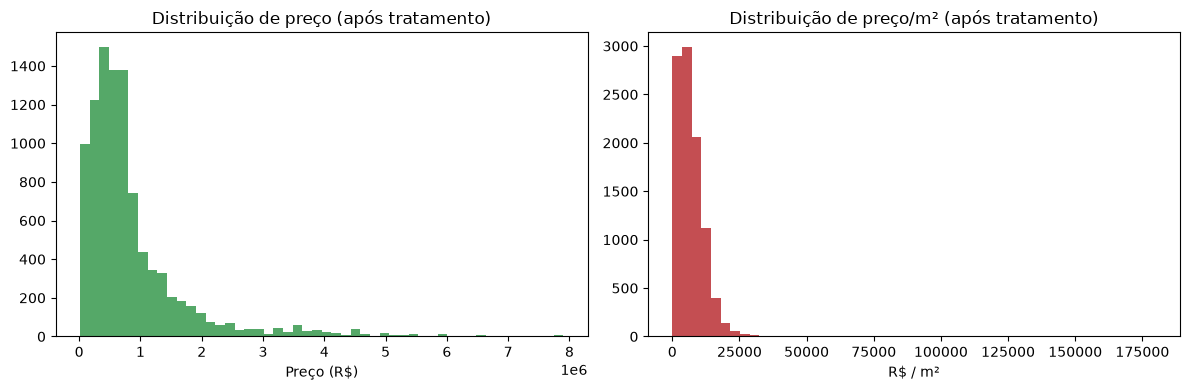

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["preco_anuncio"].dropna(), bins=50, color="#55A868")
axes[0].set_title("Distribuição de preço (após tratamento)")
axes[0].set_xlabel("Preço (R$)")
axes[1].hist(df["preco_m2"].dropna(), bins=50, color="#C44E52")
axes[1].set_title("Distribuição de preço/m² (após tratamento)")
axes[1].set_xlabel("R$ / m²")
plt.tight_layout()
plt.show()


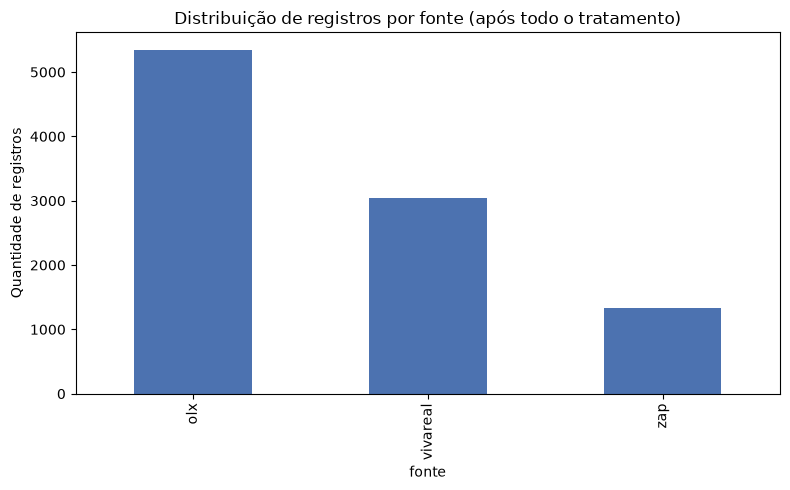

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
df["fonte"].value_counts().plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Distribuição de registros por fonte (após todo o tratamento)")
ax.set_ylabel("Quantidade de registros")
plt.tight_layout()
plt.show()


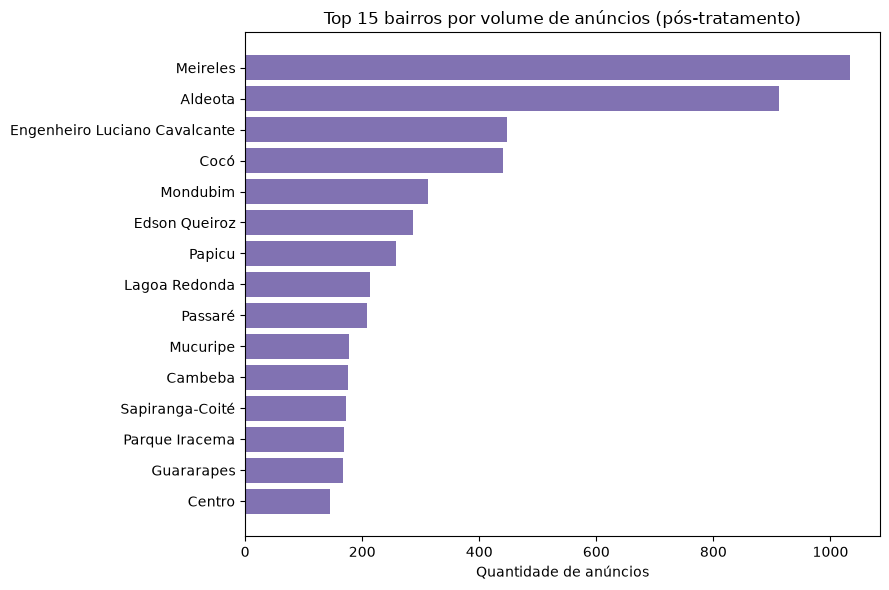

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
top_bairros = df["bairro_normalizado"].value_counts().head(15)
ax.barh(top_bairros.index[::-1], top_bairros.values[::-1], color="#8172B2")
ax.set_title("Top 15 bairros por volume de anúncios (pós-tratamento)")
ax.set_xlabel("Quantidade de anúncios")
plt.tight_layout()
plt.show()


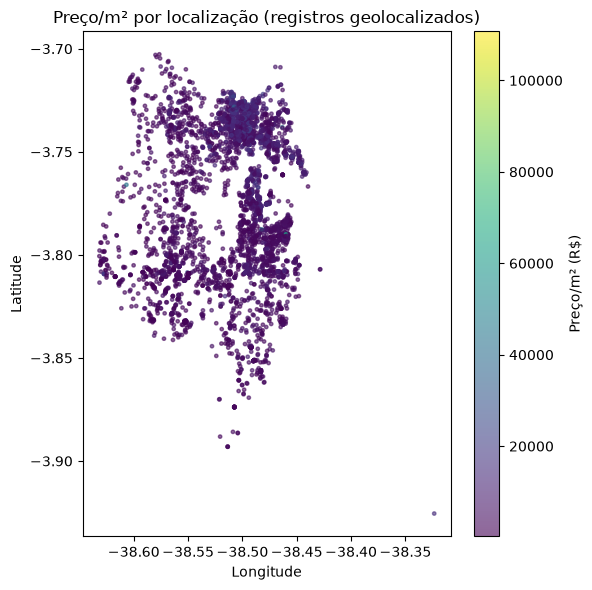

In [ ]:
geo_final = df.dropna(subset=["latitude", "longitude"])
fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(geo_final["longitude"], geo_final["latitude"], c=geo_final["preco_m2"],
                cmap="viridis", s=6, alpha=0.6)
plt.colorbar(sc, ax=ax, label="Preço/m² (R$)")
ax.set_title("Preço/m² por localização (registros geolocalizados)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()


**Leitura dos gráficos:** a distribuição de preço e preço/m² após o tratamento segue um formato
assimétrico à direita esperado para o mercado imobiliário, sem os valores grosseiramente extremos observados
antes do corte de outliers. O mapa de dispersão mostra concentração de imóveis de preço/m² mais alto próximo à
orla (Meireles/Aldeota/Praia do Futuro), validando — ainda que de forma exploratória — a utilidade das
features de distância criadas na Seção 13 para um futuro modelo preditivo.

## 15. Relatório final de tratamento

Consolidamos o histórico de transformações em um relatório único, cobrindo volume de registros, colunas
removidas e o tratamento aplicado a cada feature de interesse do projeto.

In [ ]:
print("="*70)
print("RELATÓRIO FINAL — TRATAMENTO DE DADOS")
print("="*70)
print(f"Registros iniciais (3 fontes consolidadas): {n_inicial}")
print(f"Registros finais (após todo o tratamento):  {n_final}")
print(f"Registros removidos:                        {n_inicial - n_final} "
      f"({(n_inicial - n_final) / n_inicial * 100:.1f}%)")
print()
print("Colunas removidas: ", colunas_remover)
print()
print("Detalhamento de remoção por etapa:")
print(resumo_filtros.to_string(index=False))


RELATÓRIO FINAL — TRATAMENTO DE DADOS
Registros iniciais (3 fontes consolidadas): 12292
Registros finais (após todo o tratamento):  9727
Registros removidos:                        2565 (20.9%)

Colunas removidas:  ['nota_media']

Detalhamento de remoção por etapa:
                        etapa  registros_restantes  removidos_na_etapa
        Inicial (consolidado)                12292                   0
         Dedup por listing_id                10567               -1725
           Dedup por conteúdo                10303                -264
                   Filtro RMF                10303                   0
           Escopo residencial                10242                 -61
           Cortes de outliers                10000                -242
Sem preço/metragem (removido)                 9727                -273


In [ ]:
mapa_renomeacao = {
    "apartamento_ou_casa": "tipo",
    "cidade_validada": "cidade",
    "bairro_normalizado": "bairro",
    "numero": "numero_endereco",
    "endereco": "endereco",
    "metragem": "area_m2",
    "quartos": "quartos",
    "banheiros_validado": "banheiros",
    "suites_validado": "suites",
    "andar": "andar",
    "vagas_validado": "vagas",
    "preco_anuncio": "preco",
    "preco_m2": "preco_m2",
    "latitude": "latitude",
    "longitude": "longitude",
    "tem_portaria_24h": "portaria",
    "tem_vista_pro_mar": "vista_mar",
    "tem_condominio_fechado": "condominio_fechado",
    "tem_piscina": "piscina",
    "tem_deck": "deck",
    "tem_varanda_gourmet": "varanda_gourmet",
    "tem_varanda": "varanda",
    "tem_academia": "academia",
    "tem_salao_festas": "salao_festa",
    "tem_salao_jogos": "salao_jogos",
    "tem_quadra_campo": "quadra_campo",
    "estado": "estado",
}

colunas_extra = [
    "listing_id", "titulo", "tipo_imovel_padronizado", "rua",
    "tem_geolocalizacao", "tem_endereco_estruturado", "andar_informado",
    "distancia_mar", "distancia_meireles", "distancia_aldeota", "distancia_centro",
    "fonte", "anuncio_criado", "corretora", "url",
]

df_final = df[list(mapa_renomeacao.keys()) + colunas_extra].rename(columns=mapa_renomeacao)

print("Shape do dataset final de modelagem:", df_final.shape)
df_final.head(5)


Shape do dataset final de modelagem: (9727, 42)


,tipo,cidade,bairro,numero_endereco,endereco,area_m2,quartos,banheiros,suites,andar,vagas,preco,preco_m2,latitude,longitude,portaria,vista_mar,condominio_fechado,piscina,deck,varanda_gourmet,varanda,academia,salao_festa,salao_jogos,quadra_campo,estado,listing_id,titulo,tipo_imovel_padronizado,rua,tem_geolocalizacao,tem_endereco_estruturado,andar_informado,distancia_mar,distancia_meireles,distancia_aldeota,distancia_centro,fonte,anuncio_criado,corretora,url
0,apartamento,Fortaleza,Aldeota,NaN,NaN,117.0,3.0,5.0,NaN,NaN,2.0,1500000.0,12820.512821,NaN,NaN,False,False,False,False,False,False,True,False,False,False,False,CE,1394023483,Meet Aldeota (Nunca habitado),apartamento_padrao,NaN,False,False,False,NaN,NaN,NaN,NaN,olx,2026-06-21T04:19:58+00:00,NaN,https://ce.olx.com.br/fortaleza-e-regiao/imove...
1,apartamento,Fortaleza,Joaquim Távora,NaN,NaN,100.0,3.0,2.0,NaN,NaN,2.0,199000.0,1990.000000,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,CE,1512158415,Venda Apartamento Joaquim TAvora 3 quartos,apartamento_padrao,NaN,False,False,False,NaN,NaN,NaN,NaN,olx,2026-06-21T04:15:59+00:00,NaN,https://ce.olx.com.br/fortaleza-e-regiao/imove...
2,apartamento,Fortaleza,Mucuripe,NaN,NaN,210.0,4.0,5.0,NaN,NaN,4.0,3200000.0,15238.095238,NaN,NaN,False,False,False,False,False,False,True,False,False,False,False,CE,993964795,EDIFÍCIO COSTAMARE,apartamento_padrao,NaN,False,False,False,NaN,NaN,NaN,NaN,olx,2026-06-21T03:49:48+00:00,NaN,https://ce.olx.com.br/fortaleza-e-regiao/imove...
3,apartamento,Fortaleza,Meireles,NaN,NaN,254.0,4.0,2.0,NaN,NaN,5.0,3300000.0,12992.125984,NaN,NaN,False,False,False,False,False,False,True,False,False,False,False,CE,993964994,Edifício Icon,apartamento_padrao,NaN,False,False,False,NaN,NaN,NaN,NaN,olx,2026-06-21T03:48:44+00:00,NaN,https://ce.olx.com.br/fortaleza-e-regiao/imove...
5,apartamento,Fortaleza,Meireles,NaN,NaN,254.0,4.0,5.0,NaN,NaN,4.0,4500000.0,17716.535433,NaN,NaN,False,False,False,False,False,False,True,False,False,False,False,CE,993964568,EDIFÍCIO CATAMARÃ,apartamento_padrao,NaN,False,False,False,NaN,NaN,NaN,NaN,olx,2026-06-21T03:48:42+00:00,NaN,https://ce.olx.com.br/fortaleza-e-regiao/imove...


### Tratamento aplicado a cada feature de interesse

| Feature | Tratamento aplicado |
|---|---|
| `tipo` | Mantida (`apartamento`/`casa`); detalhamento adicional em `tipo_imovel_padronizado` |
| `estado` | Mantida sem alteração (valor único: `CE`) |
| `numero_endereco` | Valores inválidos (`undefined`, `S/N`, `SN`, "sem número") convertidos para `NaN` |
| `suites` | Validada para nunca exceder `quartos` (`suites_validado`) |
| `andar` | Mantido com nulo explícito; flag `andar_informado` criada |
| `portaria`, `vista_mar`, `condominio_fechado`, `piscina`, `deck`, `varanda_gourmet`, `varanda`, `academia`, `salao_festa`, `salao_jogos`, `quadra_campo` | Convertidas de `int` (0/1) para `bool` |
| `vagas` | Truncada em `[0, 12]` (`vagas_validado`), removendo valores de domínio implausível |
| `endereco` | Mantido; flag `tem_endereco_estruturado` indica ausência estrutural por fonte (OLX) |
| `area_m2` (`metragem`) | Cortada no percentil 99.5 (apenas imóveis residenciais); registros sem valor foram removidos (variável central ao problema) |
| `latitude`/`longitude` | Mantidas com nulo explícito; flag `tem_geolocalizacao`; validada bounding box da RMF |
| `cidade` | Substituída pela versão validada via texto (`cidade_validada`), corrigindo o valor estrutural fixo `"Fortaleza"`; filtrada para a RMF |
| `bairro` | Grafias divergentes padronizadas para forma canônica |
| `preco` (`preco_anuncio`) | Removidos valores `< R$ 10.000` e cortados no percentil 99.5; registros sem valor foram removidos |
| `preco_m2` | Atributo derivado: `preco / area_m2` |
| `quartos` | Limite de domínio aplicado (`≤ 15`) |
| `banheiros` | Validado para nunca ser menor que `suites_validado` |


In [ ]:
df_final.info()

<class 'pandas.DataFrame'>
Index: 9727 entries, 0 to 12291
Data columns (total 42 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   tipo                      9727 non-null   str    
 1   cidade                    9727 non-null   str    
 2   bairro                    9726 non-null   str    
 3   numero_endereco           3154 non-null   object 
 4   endereco                  4377 non-null   object 
 5   area_m2                   9727 non-null   float64
 6   quartos                   9721 non-null   float64
 7   banheiros                 9716 non-null   float64
 8   suites                    3763 non-null   float64
 9   andar                     4353 non-null   float64
 10  vagas                     9509 non-null   float64
 11  preco                     9727 non-null   float64
 12  preco_m2                  9721 non-null   float64
 13  latitude                  4369 non-null   float64
 14  longitude              

In [ ]:
df_final[["preco", "area_m2", "preco_m2"]].describe()

,preco,area_m2,preco_m2
count,9.727000e+03,9727.000000,9721.000000
mean,8.670506e+05,136.111134,6921.197165
std,9.405650e+05,108.937661,5726.885581
min,1.200000e+04,0.000000,34.285714
25%,3.500000e+05,62.000000,3214.285714
50%,6.000000e+05,105.000000,5553.333333
75%,9.899950e+05,167.000000,9716.981132
max,7.900000e+06,810.000000,180000.000000


In [ ]:
df_final["cidade"].value_counts()

cidade
Fortaleza    9645
Eusébio        38
Aquiraz        20
Horizonte       8
Maracanaú       5
Itaitinga       3
Caucaia         3
Trairi          1
Pacatuba        1
Cascavel        1
Pacajus         1
Paracuru        1
Name: count, dtype: int64

In [ ]:
df_final["tipo"].value_counts()

tipo
apartamento    6362
casa           3365
Name: count, dtype: int64

In [ ]:
print("=" * 50)
print("SHAPE")
print(df_final.shape)

print("\n" + "=" * 50)
print("TIPOS")
print(df_final.dtypes.value_counts())

print("\n" + "=" * 50)
print("NULOS (%)")
print((df_final.isnull().mean() * 100).sort_values(ascending=False).head(15))

print("\n" + "=" * 50)
print("COLUNAS BOOLEANAS")
bool_cols = df_final.select_dtypes(include="bool").columns

for col in bool_cols:
    print(f"{col}: {df_final[col].mean()*100:.2f}% True")

print("\n" + "=" * 50)
print("CIDADES")
print(df_final["cidade"].value_counts().head(10))

print("\n" + "=" * 50)
print("TIPOS DE IMÓVEL")
print(df_final["tipo"].value_counts())

print("\n" + "=" * 50)
print("NUMÉRICAS")
print(df_final.describe())

SHAPE
(9727, 42)

TIPOS
float64    14
bool       14
str         8
object      5
int64       1
Name: count, dtype: int64

NULOS (%)
numero_endereco       67.574792
suites                61.313869
rua                   58.579213
andar                 55.248278
distancia_meireles    55.083787
distancia_centro      55.083787
longitude             55.083787
distancia_aldeota     55.083787
latitude              55.083787
distancia_mar         55.083787
endereco              55.001542
corretora             55.001542
anuncio_criado        44.998458
vagas                  2.241184
url                    0.164491
dtype: float64

COLUNAS BOOLEANAS
portaria: 15.17% True
vista_mar: 5.64% True
condominio_fechado: 14.09% True
piscina: 42.05% True
deck: 14.41% True
varanda_gourmet: 8.81% True
varanda: 48.75% True
academia: 30.94% True
salao_festa: 19.72% True
salao_jogos: 9.46% True
quadra_campo: 19.57% True
tem_geolocalizacao: 44.92% True
tem_endereco_estruturado: 45.00% True
andar_informado: 44.75% 

In [ ]:
# remover colunas que não serão utilizadas no modelo, mantendo apenas as essenciais
colunas_remover = [
    "numero_endereco",
    "rua",
    "endereco",
    "latitude",
    "longitude",
    "distancia_mar",
    "distancia_meireles",
    "distancia_aldeota",
    "distancia_centro",
    "corretora",
    "anuncio_criado",
    "url",
    "titulo",
    "listing_id",
    "fonte"
]

df_final = df_final.drop(
    columns=[c for c in colunas_remover if c in df_final.columns]
)

# remover registros com valores nulos nas colunas essenciais para o modelo
colunas_essenciais = [
    "tipo",
    "estado",
    "bairro",
    "area_m2",
    "preco",
    "vagas",
    "quartos",
    "banheiros",
    "suites",
    "andar"
]

df_final = df_final.dropna(subset=colunas_essenciais)

# remover registros com preço ou área inválidos (menor ou igual a zero)
df_final = df_final[df_final["preco"] > 0]
df_final = df_final[df_final["area_m2"] > 0]

# exibir informações finais sobre o dataset tratado
print("Shape final:", df_final.shape)

print("\nNulos restantes (%):")
print(
    (df_final.isnull().mean() * 100)
    .sort_values(ascending=False)
    .head(10)
)

print("\nTipos de imóvel:")
print(df_final["tipo"].value_counts())

print("\nCidades:")
print(df_final["cidade"].value_counts())

Shape final: (3711, 27)

Nulos restantes (%):
tipo         0.0
cidade       0.0
bairro       0.0
area_m2      0.0
quartos      0.0
banheiros    0.0
suites       0.0
andar        0.0
vagas        0.0
preco        0.0
dtype: float64

Tipos de imóvel:
tipo
apartamento    2001
casa           1710
Name: count, dtype: int64

Cidades:
cidade
Fortaleza    3675
Eusébio        22
Aquiraz        13
Caucaia         1
Name: count, dtype: int64


In [ ]:
df_final.shape

(3711, 27)

In [ ]:
from pathlib import Path

OUTPUT_DIR = Path("dados_tratados")
OUTPUT_DIR.mkdir(exist_ok=True)

OUTPUT_PATH = OUTPUT_DIR / "imoveis_tratado.csv"

df_final.to_csv(OUTPUT_PATH, index=False)

print(f"Dataset salvo em: {OUTPUT_PATH}")
print(f"Shape final: {df_final.shape}")

Dataset salvo em: dados_tratados\imoveis_tratado.csv
Shape final: (3711, 27)


In [ ]:
df_final["preco"] = pd.to_numeric(df_final["preco"], errors="coerce")

correlacoes_preco = (
    df_final
    .corr(numeric_only=True)["preco"]
    .drop("preco")
    .sort_values(ascending=False)
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))

sns.barplot(
    x=correlacoes_preco.values,
    y=correlacoes_preco.index,
    hue=correlacoes_preco.index,
    palette="coolwarm",
    legend=False
)

plt.title("Correlação das features com o preço")
plt.xlabel("Correlação com preco")
plt.ylabel("Features")

plt.show()

NameError: name 'pd' is not defined